In [51]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, Dropout
from tensorflow.keras import backend as K
from tensorflow.keras.losses import mse


In [52]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
input_shape = x_train.shape[1:]


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [53]:
# Encoder
inputs = Input(shape=input_shape)
x = Flatten()(inputs)
x = Dense(128, activation='relu')(x)
encoded = Dense(64, activation='relu')(x)

# Decoder
x = Dense(128, activation='relu')(encoded)
x = Dense(np.prod(input_shape), activation='sigmoid')(x)
decoded = Reshape(input_shape)(x)

autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
history = autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)


Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.4465 - val_loss: 0.3123
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3043 - val_loss: 0.2975
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2943 - val_loss: 0.2921
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2892 - val_loss: 0.2884
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2852 - val_loss: 0.2865
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2830 - val_loss: 0.2841
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2814 - val_loss: 0.2826
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2803 - val_loss: 0.2820
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2782 - val_loss: 0.2805
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2785 - val_loss: 0.2794
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2767 - val_loss: 0.2786
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step


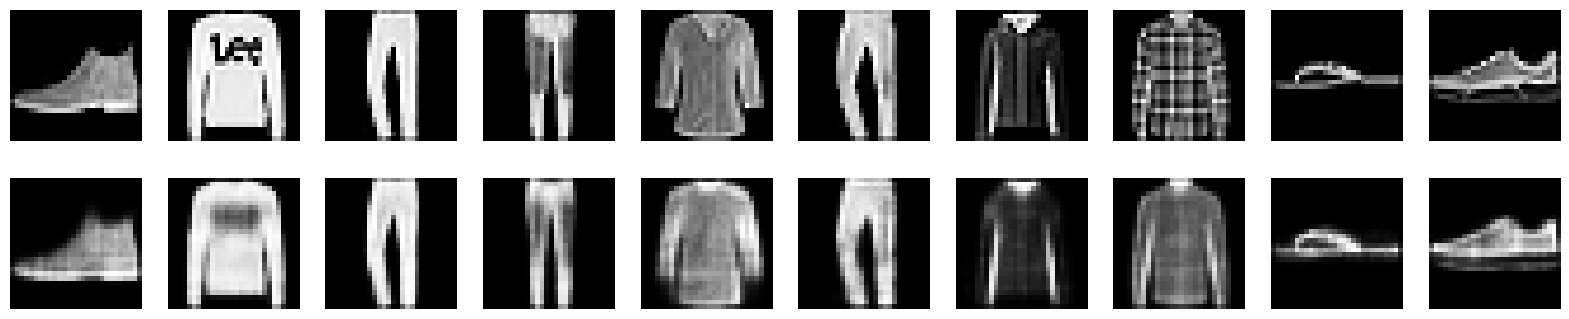

In [55]:
decoded_imgs = autoencoder.predict(x_test[:10])

plt.figure(figsize=(20,4))
for i in range(10):
    # Original
    ax = plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2,10,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.show()


In [56]:
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Reuse the same architecture
denoising_autoencoder = Model(inputs, decoded)
denoising_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
denoising_autoencoder.fit(x_train_noisy, x_train,
                          epochs=20, batch_size=256,
                          validation_data=(x_test_noisy, x_test))


Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3281 - val_loss: 0.3033
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2989 - val_loss: 0.2990
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2961 - val_loss: 0.2979
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2941 - val_loss: 0.2972
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2941 - val_loss: 0.2957
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2923 - val_loss: 0.2955
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2917 - val_loss: 0.2949
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2921 - val_loss: 0.2948
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2908 - val_loss: 0.2946
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2902 - val_loss: 0.2941
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2912 - val_loss: 0.2958
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


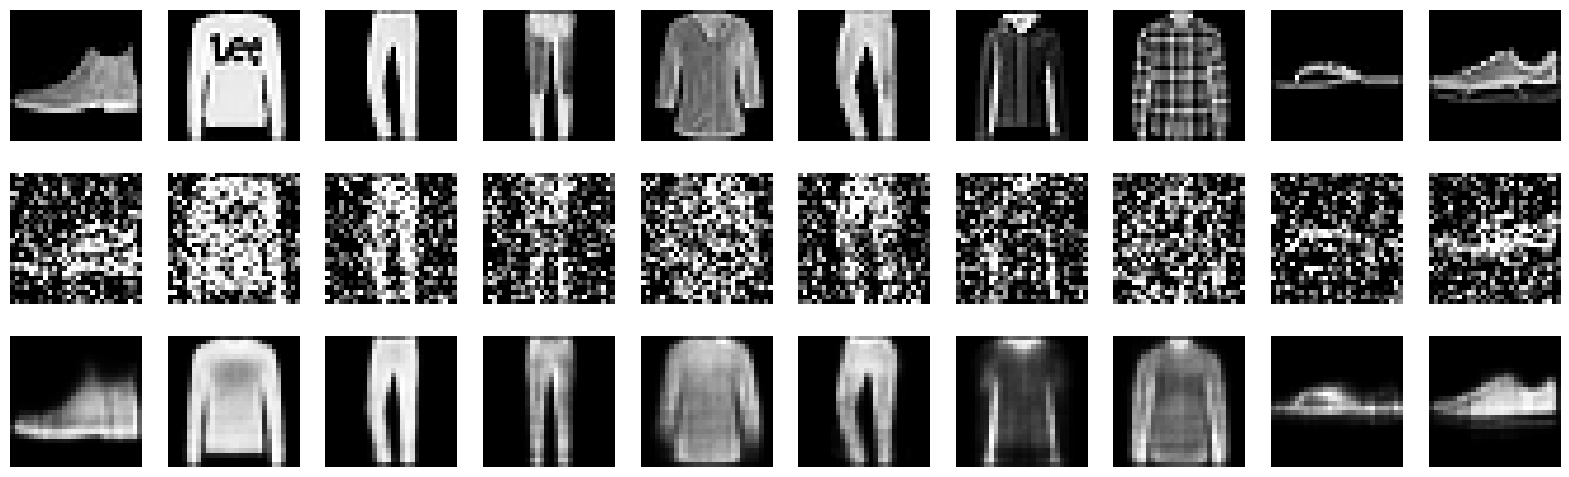

In [61]:
# Predict on noisy test images
decoded_noisy = denoising_autoencoder.predict(x_test_noisy[:10])

plt.figure(figsize=(20,6))
for i in range(10):
    # Original
    ax = plt.subplot(3,10,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    if i == 0: plt.ylabel("Original")

    # Noisy
    ax = plt.subplot(3,10,i+11)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    if i == 0: plt.ylabel("Noisy")

    # Reconstructed
    ax = plt.subplot(3,10,i+21)
    plt.imshow(decoded_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    if i == 0: plt.ylabel("Reconstructed")
plt.show()


In [64]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import fashion_mnist

# Load data
(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

latent_dim = 2

# Encoder
class Encoder(Model):
    def __init__(self, latent_dim):
        super().__init__()
        self.flatten = layers.Flatten()
        self.dense1 = layers.Dense(128, activation="relu")
        self.z_mean = layers.Dense(latent_dim)
        self.z_log_var = layers.Dense(latent_dim)

    def call(self, x):
        x = self.flatten(x)
        x = self.dense1(x)
        z_mean = self.z_mean(x)
        z_log_var = self.z_log_var(x)
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        z = z_mean + tf.exp(0.5 * z_log_var) * epsilon
        return z, z_mean, z_log_var

# Decoder
class Decoder(Model):
    def __init__(self):
        super().__init__()
        self.dense1 = layers.Dense(128, activation="relu")
        self.dense2 = layers.Dense(28*28, activation="sigmoid")
        self.reshape = layers.Reshape((28,28,1))

    def call(self, z):
        x = self.dense1(z)
        x = self.dense2(x)
        x = self.reshape(x)
        return x

# VAE
class VAE(Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, x):
        z, z_mean, z_log_var = self.encoder(x)
        x_recon = self.decoder(z)
        # Compute loss
        recon_loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(x, x_recon)) * 28*28
        kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        self.add_loss(recon_loss + kl_loss)
        return x_recon

encoder = Encoder(latent_dim)
decoder = Decoder()
vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")
vae.summary()

vae.fit(x_train, x_train, epochs=20, batch_size=256, validation_data=(x_test, x_test))


Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Encoder)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Decoder)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 400.4292 - val_loss: 290.6548
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 286.2715 - val_loss: 281.9870
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 279.4171 - val_loss: 278.6351
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 276.7950 - val_loss: 275.9340
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 274.4711 - val_loss: 273.7604
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 272.0183 - val_loss: 271.8612
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 270.3952 - val_loss: 270.8747
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 269.0122 - val_loss: 269.4437
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 268.5587 - val_loss: 268.8542
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 267.3356 - val_loss: 268.0402
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 266.6178 - val_loss: 267.4271
Epoch 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 825ms/step


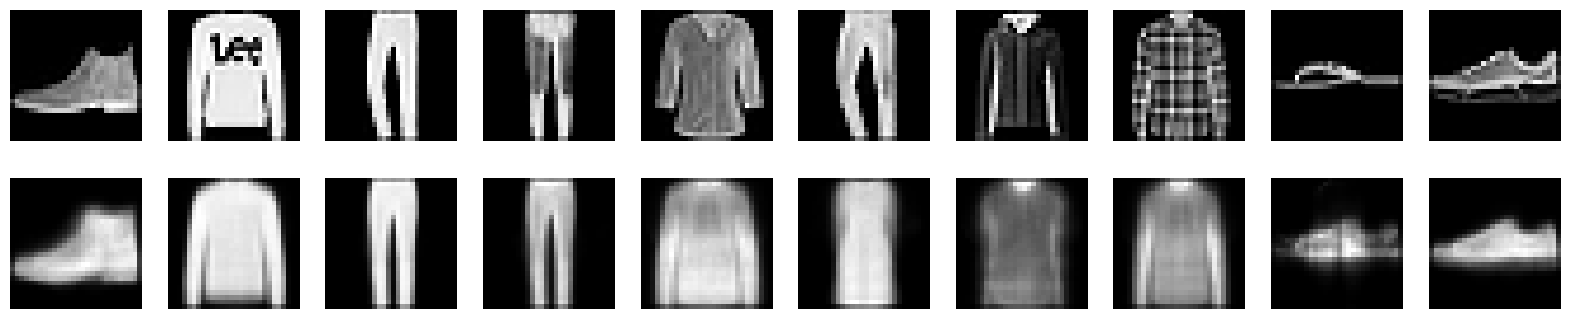

In [65]:
decoded_vae = vae.predict(x_test[:10])

plt.figure(figsize=(20,4))
for i in range(10):
    # Original
    ax = plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    if i == 0: plt.ylabel("Original")

    # VAE Reconstructed
    ax = plt.subplot(2,10,i+11)
    plt.imshow(decoded_vae[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    if i == 0: plt.ylabel("VAE Reconstructed")
plt.show()


In [58]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv', sep=';')
data = df.values.astype('float32')
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


In [59]:
input_dim = data_scaled.shape[1]
inputs = Input(shape=(input_dim,))
encoded = Dense(10, activation='relu')(inputs)
encoded = Dense(5, activation='relu')(encoded)
decoded = Dense(10, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

tab_autoencoder = Model(inputs, decoded)
tab_autoencoder.compile(optimizer='adam', loss='mse')
tab_autoencoder.summary()
tab_autoencoder.fit(data_scaled, data_scaled, epochs=50, batch_size=32, validation_split=0.2)


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 12)             │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 377 (1.47 KB)

 Trainable params: 377 (1.47 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0801 - val_loss: 0.0748
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0700 - val_loss: 0.0583
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0528 - val_loss: 0.0373
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0362 - val_loss: 0.0247
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0255 - val_loss: 0.0206
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0221 - val_loss: 0.0196
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0201 - val_loss: 0.0195
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0203 - val_loss: 0.0194
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0200 - val_loss: 0.0191
Epoch 10/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0199 - val_loss: 0.0189
Epoch 11/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0196 - val_loss: 0.0186
Epoch 12/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0198 - val_l

In [60]:
reconstructed = tab_autoencoder.predict(data_scaled[:10])
print("Original Data (first 5 rows):")
print(data_scaled[:5])
print("\nReconstructed Data (first 5 rows):")
print(reconstructed[:5])


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 570ms/step
Original Data (first 5 rows):
[[0.24778762 0.39726025 0.         0.06849314 0.10684474 0.14084508
  0.09893993 0.567543   0.6062989  0.13772453 0.15384614 0.39999998]
 [0.28318587 0.520548   0.         0.11643834 0.14357261 0.33802816
  0.2155477  0.49412537 0.36220455 0.20958082 0.2153846  0.39999998]
 [0.28318587 0.43835616 0.04       0.0958904  0.13355593 0.1971831
  0.1696113  0.5088043  0.40944862 0.19161676 0.2153846  0.39999998]
 [0.5840708  0.10958904 0.56       0.06849314 0.1051753  0.22535211
  0.19081272 0.5822296  0.3307085  0.1497006  0.2153846  0.6       ]
 [0.24778762 0.39726025 0.         0.06849314 0.10684474 0.14084508
  0.09893993 0.567543   0.6062989  0.13772453 0.15384614 0.39999998]]

Reconstructed Data (first 5 rows):
[[0.18162183 0.41308296 0.08718974 0.08853617 0.10685588 0.22622307
  0.16336946 0.45433453 0.559232   0.14645936 0.21760337 0.3999756 ]
 [0.22393996 0.40169016 0.12449286 0.10491104 0.13301195 0.2734248
  0.23